# Importing Libraries

In [ ]:
# Importing essential libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing libraries for handling imbalanced datasets
from imblearn.over_sampling import SMOTE
from collections import Counter

# Importing libraries for preprocessing
from sklearn.preprocessing import StandardScaler

# Importing libraries for model training and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report

# Importing visualization tools from Yellowbrick
from yellowbrick.classifier import ConfusionMatrix
from yellowbrick.classifier import ClassPredictionError
from yellowbrick.classifier import ROCAUC
from yellowbrick.style import set_palette


from sklearn.model_selection import train_test_split

# Importing XGBoost library
from xgboost import XGBClassifier, plot_tree

# 1. Load Data into a Pandas DataFrame

Code Block 1A

In [31]:
# Define the file path to the CSV file
csv_path = '../data/stellar_data.csv'  # Path relative to the notebook location

# Read the CSV file into a Pandas DataFrame
df = pd.read_csv(csv_path)

# Display the first 5 rows of the DataFrame to understand its structure and data
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [32]:
df['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

# 2. Preprocessing

## 2.1 Label Encoding

Code Block 2A

In [33]:
# Define the mapping dictionary
class_mapping = {"GALAXY": 0, "STAR": 1, "QSO": 2}

# Map the values using the dictionary
df["class"] = df["class"].map(class_mapping)

df['class'].unique()

array([0, 2, 1])

## 2.2 Detecting Outliers

Code Block 2B

In [ ]:

from sklearn.neighbors import LocalOutlierFactor


clf = LocalOutlierFactor()


y_pred = clf.fit_predict(df)

Code Block 2C

In [ ]:
# Retrieve the negative outlier factor for each data point
# This factor indicates how much a point deviates from its neighbors; lower values indicate stronger outliers
x_score = clf.negative_outlier_factor_

# Create a DataFrame to store the outlier scores for better analysis and manipulation
outlier_score = pd.DataFrame()
outlier_score["score"] = x_score


threshold2 = -1.5

filtre2 = outlier_score["score"] < threshold2

outlier_index = outlier_score[filtre2].index.tolist()


print(len(outlier_index))

15256


Code Block 2D

In [36]:
# Remove the rows corresponding to the detected outliers from the DataFrame
# 'outlier_index' contains the indices of the outliers, and 'inplace=True' modifies the DataFrame directly
df.drop(outlier_index, inplace=True)

## 2.3 Feature Selection

In [37]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,2,0.586455,11069,58456,113


Code Block 2E

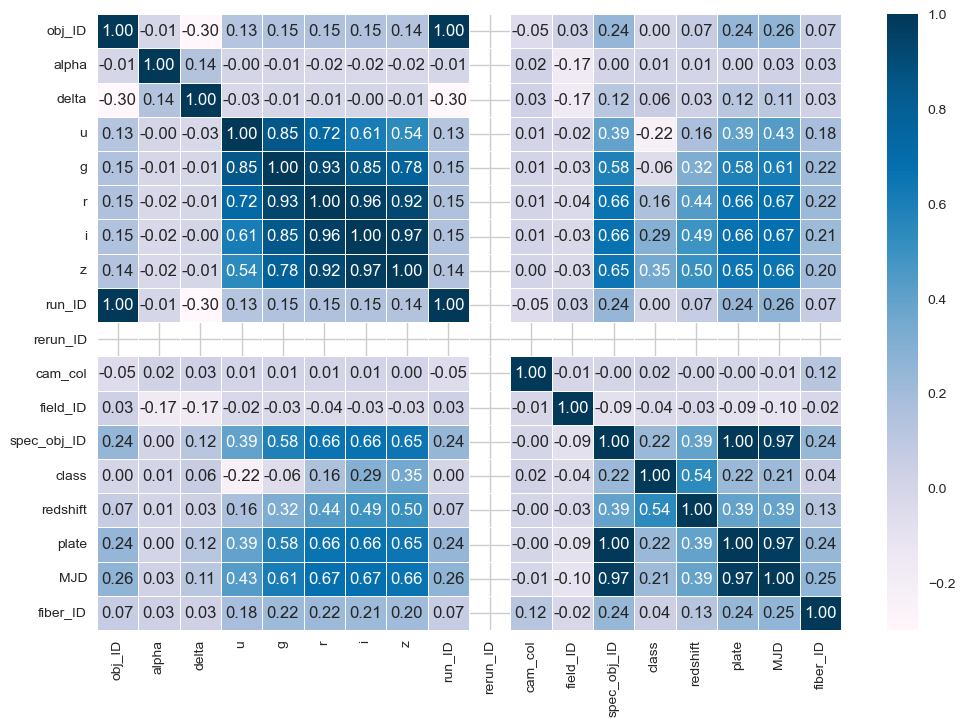

In [38]:
# Create a figure and axes for the plot, specifying the figure size
f, ax = plt.subplots(figsize=(12, 8))

# Generate a heatmap to visualize the correlation matrix of the DataFrame
# - 'df.corr()' computes pairwise correlation between numerical features
# - 'cmap="PuBu"' specifies the color palette for the heatmap
# - 'annot=True' displays the correlation values on the heatmap
# - 'linewidths=0.5' sets the width of the lines separating the cells
# - 'fmt=".2f"' formats the correlation values to 2 decimal places
sns.heatmap(df.corr(), cmap="PuBu", annot=True, linewidths=0.5, fmt='.2f', ax=ax)

# Display the heatmap
plt.show()

In [39]:
df['rerun_ID'].unique()

array([301])

Code Block 2F

In [40]:
# Compute the correlation matrix for the DataFrame
# This calculates the pairwise correlation between all numerical features
corr = df.corr()

# Extract and sort the correlation values for the 'class' column
# Sorting helps identify the strongest positive and negative correlations with the target variable ('class')
corr["class"].sort_values()

u             -0.222802
g             -0.058192
field_ID      -0.037542
run_ID         0.000250
obj_ID         0.000252
alpha          0.008187
cam_col        0.017789
fiber_ID       0.037319
delta          0.058947
r              0.160654
MJD            0.214433
spec_obj_ID    0.224718
plate          0.224718
i              0.294075
z              0.349711
redshift       0.541667
class          1.000000
rerun_ID            NaN
Name: class, dtype: float64

Code Block 2G

In [41]:
# Select only the 6 features needed for the frontend
# Keep only: u, g, r, i, z, redshift
selected_features = ['u', 'g', 'r', 'i', 'z', 'redshift']

# Keep only the selected features in the dataframe
df = df[selected_features + ['class']]

print(f"Selected features: {selected_features}")
print(f"DataFrame shape: {df.shape}")
df.head()

Selected features: ['u', 'g', 'r', 'i', 'z', 'redshift']
DataFrame shape: (84744, 7)


,u,g,r,i,z,redshift,class
0,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794,0
1,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136,0
3,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346,0
4,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123,0
6,21.46973,21.17624,20.92829,20.60826,20.42573,0.586455,2


## 2.4 Handling Imbalanced Data

Code Block 2H

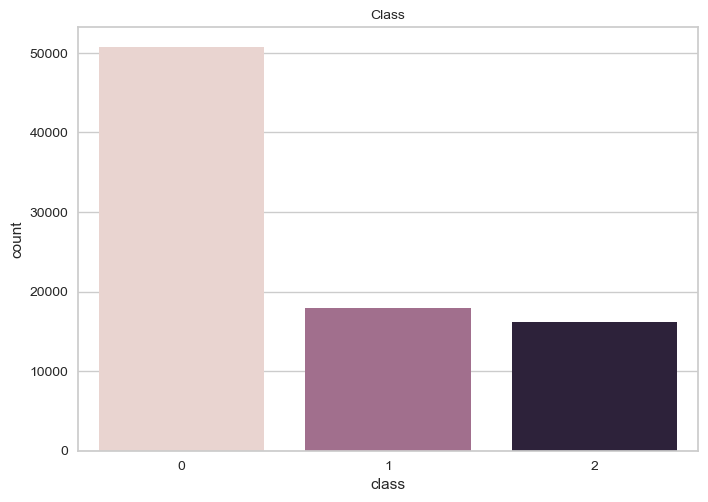

In [42]:
# Create a count plot to visualize the distribution of the 'class' column
# The 'hue' parameter is also set to 'class', which differentiates each bar by its own class
sns.countplot(data=df, x="class", hue="class", legend=False)

# Set the title of the plot with a specified font size
plt.title("Class", fontsize=10)

# Display the plot
plt.show()

Code Block 2I

In [43]:
# Separate the features (X) and target variable (y)
# 'x' contains all columns except 'class', which will be used as features
X = df.drop(['class'], axis=1)

# 'y' contains the 'class' column as the target variable for classification
# The '.values' extracts the values as a numpy array
y = df.loc[:, 'class'].values

Code Block 2J

In [44]:
# Initialize the SMOTE (Synthetic Minority Over-sampling Technique) object with a fixed random seed for reproducibility
sm = SMOTE(random_state=42)

# Print the original class distribution of the target variable 'y'
# Counter(y) shows the count of each class before resampling
print('Original dataset shape %s' % Counter(y))

# Apply SMOTE to resample the dataset, generating synthetic examples for the minority class
# The fit_resample method balances the class distribution by generating synthetic samples
X, y = sm.fit_resample(X, y)

# Print the new class distribution of the target variable 'y' after resampling
# Counter(y) shows the count of each class after resampling
print('Resampled dataset shape %s' % Counter(y))

Original dataset shape Counter({np.int64(0): 50695, np.int64(1): 17890, np.int64(2): 16159})
Resampled dataset shape Counter({np.int64(0): 50695, np.int64(2): 50695, np.int64(1): 50695})


Code Block 2K

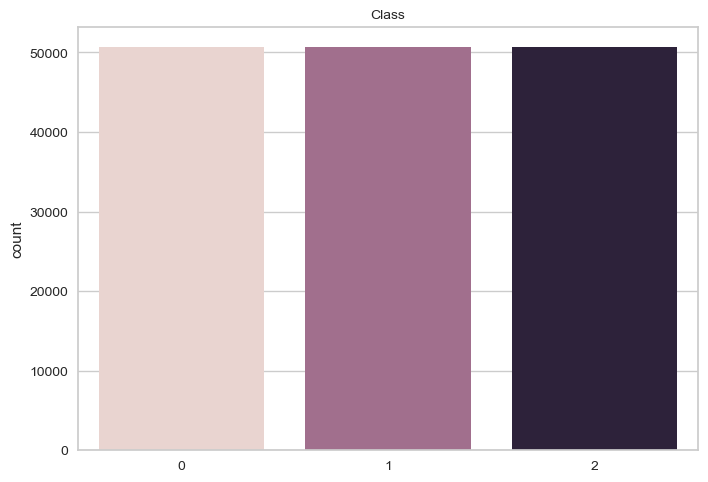

In [45]:
# Create a count plot to visualize the distribution of the target variable 'y' (class)
# The 'hue' is also set to 'y', which colors the bars based on the target classes
# 'legend=False' hides the legend to avoid redundancy
sns.countplot(x=y, hue=y, legend=False)

# Set the title of the plot with a specified font size
plt.title("Class", fontsize=10)

# Display the plot
plt.show()

## 2.5 Data Scaling

Code Block 2L

In [46]:
# Initialize a StandardScaler object for feature scaling
# StandardScaler standardizes the features by removing the mean and scaling to unit variance
scaler = StandardScaler()

# Compute the mean and standard deviation for each feature in 'x'
# This fits the scaler to the data without yet transforming it
scaler.fit(X)

# Apply the scaling transformation to 'x'
# This standardizes all features based on the mean and standard deviation computed during fitting
x = scaler.transform(X)

# 3. Split to Train and Test

Code Block 3A

In [47]:
# Split the dataset into training and testing sets
# - 'X_train' and 'y_train' will be used for training the model
# - 'X_test' and 'y_test' will be used for evaluating the model
# Parameters:
# - 'test_size=0.2': 20% of the data is reserved for testing
# - 'random_state=42': Ensures reproducibility of the split by using a fixed random seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Code Block 3B

In [48]:
# X_train, y_train: Training set (80%)
# X_test, y_test: Test set (20%)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (121668, 6)
y_train shape: (121668,)
X_test shape: (30417, 6)
y_test shape: (30417,)


# 4. Training the Model

Code Block 4A

In [49]:
# Initialize an XGBoost classifier with specified hyperparameters
# Parameters:
# - 'objective="multiclass:softmax"': Configures the model for multi-class classification
# - 'learning_rate=0.1': Determines the step size at each iteration during optimization
# - 'max_depth=5': Sets the maximum depth of the trees to control model complexity
# - 'n_estimators=50': Specifies the number of trees in the ensemble

# TODO: Adjust learning_rate, max_depth, and n_estimators
model = XGBClassifier(objective='multiclass:softmax', learning_rate=0.1, max_depth=5, n_estimators=50)

# Train the XGBoost model using the training data
# 'x_train' contains the features, and 'y_train' contains the corresponding labels
model.fit(X_train, y_train)

# Predict the class labels for the test set
# 'x_test' is the feature data for testing
preds = model.predict(X_test)

# Calculate and print the accuracy of the model
# Compares the predicted labels ('preds') with the true labels ('y_test') and computes the proportion of correct predictions
print(sum(preds == y_test) / len(y_test))

0.9724496169904987


# 5. Evaluating the Model

Code Block 5A

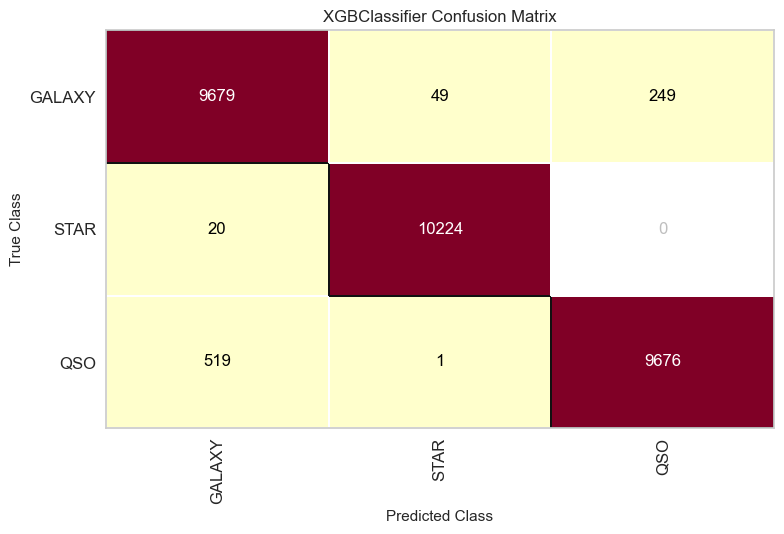

<Axes: title={'center': 'XGBClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [50]:
# Initialize a ConfusionMatrix visualizer for the XGBoost model
# Parameters:
# - 'model': The trained XGBoost model to be evaluated
# - 'classes': A list of class labels corresponding to the target variable ('GALAXY', 'STAR', 'QSO')
model_cm = ConfusionMatrix(model, classes=['GALAXY', 'STAR', 'QSO'])

# Train the visualizer with the training data
# This step trains the confusion matrix visualizer by fitting the model to the training set
model_cm.fit(X_train, y_train)

# Evaluate the model's performance on the test data
# This computes the confusion matrix based on predictions made for 'x_test' compared to true labels in 'y_test'
model_cm.score(X_test, y_test)

# Display the confusion matrix visualization
# This shows a heatmap-style representation of the confusion matrix
model_cm.show()

Code Block 5B

Classification Report

In [51]:
# Generate and display a classification report to evaluate the model's performance
# Parameters:
# - 'y_test': The true class labels for the test set
# - 'preds': The predicted class labels generated by the model
# The classification report includes metrics such as:
# - Precision: The ratio of true positives to the sum of true and false positives
# - Recall: The ratio of true positives to the sum of true positives and false negatives
# - F1-score: The harmonic mean of precision and recall
# - Support: The number of true instances for each class
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      9977
           1       1.00      1.00      1.00     10244
           2       0.97      0.95      0.96     10196

    accuracy                           0.97     30417
   macro avg       0.97      0.97      0.97     30417
weighted avg       0.97      0.97      0.97     30417



Code Block 5C

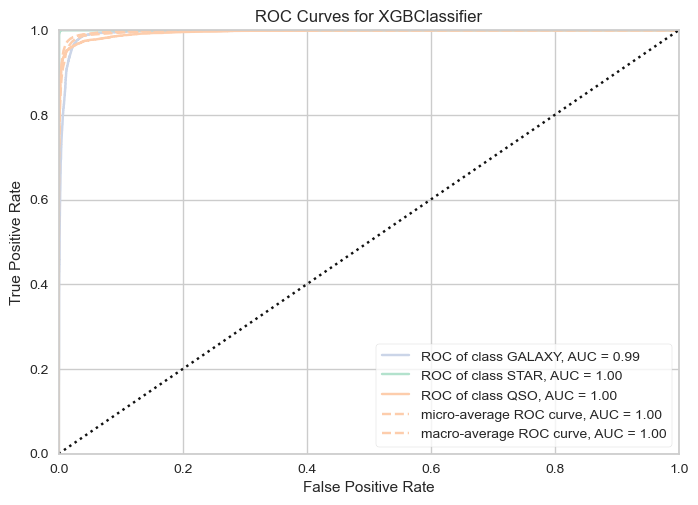

<Axes: title={'center': 'ROC Curves for XGBClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [52]:
# Initialize a ROCAUC visualizer for the XGBoost model
# Parameters:
# - 'model': The trained XGBoost model to be evaluated
# - 'classes': A list of class labels for the target variable ('GALAXY', 'STAR', 'QSO')
# The visualizer generates ROC curves for each class in a multi-class classification problem.
visualizer = ROCAUC(model, classes=['GALAXY', 'STAR', 'QSO'])

# Train the visualizer with the training data
# 'x_train' contains the features, and 'y_train' contains the corresponding labels
visualizer.fit(X_train, y_train)

# Evaluate the model's performance on the test data
# This computes the ROC AUC scores for each class based on predictions made for 'x_test'
visualizer.score(X_test, y_test)

# Display the ROC AUC visualization
# This shows the ROC curves for each class, which illustrate the trade-off between true positive rate and false positive rate
visualizer.show()

Code Block 5D

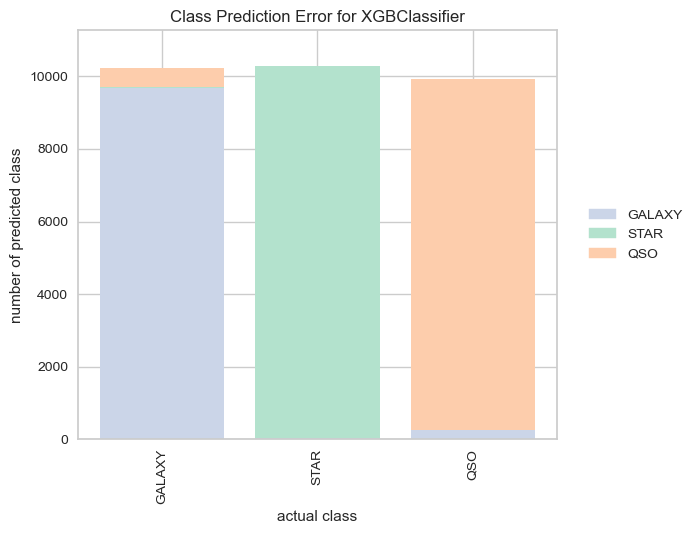

<Axes: title={'center': 'Class Prediction Error for XGBClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [53]:
# Initialize a ClassPredictionError visualizer for the XGBoost model
# Parameters:
# - 'model': The trained XGBoost model to be evaluated
# - 'classes': A list of class labels for the target variable ('GALAXY', 'STAR', 'QSO')
# This visualizer shows a bar chart of the predicted versus actual class distributions, highlighting misclassifications.
visualizer = ClassPredictionError(model, classes=['GALAXY', 'STAR', 'QSO'])

# Set the color palette for the visualizer to 'pastel'
# This changes the visual style of the chart to use softer, pastel tones
set_palette('pastel')

# Train the visualizer with the training data
# 'x_train' contains the features, and 'y_train' contains the corresponding labels
visualizer.fit(X_train, y_train)

# Evaluate the model's performance on the test data
# This computes the class prediction errors based on predictions made for 'x_test'
visualizer.score(X_test, y_test)

# Display the ClassPredictionError visualization
# This shows a bar chart of actual vs. predicted classes, highlighting areas of misclassification
visualizer.show()

In [54]:
# Save the trained model to a file in the parent directory (same level as app.py)
import joblib
joblib.dump(model, '../stellar_model.pkl')
print("Model saved successfully as 'stellar_model.pkl' in backend_stellar folder")

Model saved successfully as 'stellar_model.pkl' in backend_stellar folder


In [55]:
print(list(X.columns))

['u', 'g', 'r', 'i', 'z', 'redshift']


In [56]:
print(X.columns.tolist())

['u', 'g', 'r', 'i', 'z', 'redshift']
